# 01: TMDB Overview and Basic Cleaning of the Dataset

## Setup

### Imports & configuration

In [1]:
%matplotlib inline

import sys
import warnings
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config
from src.eda.helper import (
    parse_list_field,
    text_field_report,
)
from src.eda.loaders import load_tmdb
from src.report import log_findings, savefig

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROCESSED_DIR = config.PROCESSED_DIR
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# This notebook's own figures subdirectory (src/report.py's per-notebook
# convention) -- bound into savefig once here so every savefig(fig, filename)
# call below lands in reports/figures/01/ without repeating figures_dir.
FIGURES_DIR = config.FIGURES_DIR / "01"
savefig = partial(savefig, figures_dir=FIGURES_DIR)

### Load dataset

In [2]:
tmdb_raw = load_tmdb()

print("TMDB raw shape:", tmdb_raw.shape)

TMDB raw shape: (1456829, 24)


## 1. Structural overview

### Data provenance

In [3]:
display(Markdown(f"""
**Dataset provenance** (pulled from `src/eda/config.py`):

- TMDB download date: `{config.TMDB_DOWNLOAD_DATE}`
"""))


**Dataset provenance** (pulled from `src/eda/config.py`):

- TMDB download date: `2026-07-11`


### Shape, dtypes & column list

In [4]:
tmdb_shape_raw = tmdb_raw.shape
print("TMDB shape:", tmdb_shape_raw)

TMDB shape: (1456829, 24)


In [5]:
tmdb_raw.dtypes

id                               Int64
title                           string
vote_average                   float64
vote_count                       Int64
status                        category
release_date            datetime64[us]
revenue                        float64
runtime                        float64
adult                             bool
backdrop_path                   string
budget                         float64
homepage                        string
imdb_id                         string
original_language             category
original_title                  string
overview                        string
popularity                     float64
poster_path                     string
tagline                         string
genres                          string
production_companies            string
production_countries            string
spoken_languages                string
keywords                        string
dtype: object

### Memory usage

In [6]:
tmdb_mem_mb = tmdb_raw.memory_usage(deep=True).sum() / 1e6
print(f"TMDB memory usage (deep): {tmdb_mem_mb:,.1f} MB")

TMDB memory usage (deep): 734.2 MB


### Random sample inspection

In [7]:
tmdb_raw.sample(10, random_state=config.RANDOM_SEED)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
231924,594409,"Wild: Life, Death and Love in a Wildlife Hospital",7.0,1,Released,2018-05-18,0.0,60.0,False,<NA>,...,פרא,"Patient-doctor relationships are never easy, b...",0.600,/q101zRez2PR3WoYwyutfdODmMa5.jpg,<NA>,Documentary,<NA>,Israel,Hebrew,<NA>
359111,389489,Chas & Dave Last Orders,6.0,1,Released,2012-10-26,0.0,60.0,False,<NA>,...,Chas & Dave Last Orders,Documentary which highlights cockney duo Chas ...,0.961,/ju8am65e7pxWapYjbDWwQ5ebkr7.jpg,<NA>,"Music, Documentary",<NA>,<NA>,<NA>,<NA>
324084,371913,Renoir: Reviled and Revered,5.0,1,Released,2016-12-10,0.0,90.0,False,/srOAs76LC1MJTdk2DNBpw8YQCW5.jpg,...,Renoir: Reviled and Revered,Pierre-Auguste Renoir is known and loved for h...,0.983,/9WlaPv0KMAD2Cb7AYgtYTL1b0IB.jpg,"Beloved Impressionist, influential master or s...",Documentary,Seventh Art Productions,United Kingdom,English,"painting, artist, painter, pierre-auguste renoir"
1343707,830964,Dřevo jde s hor,0.0,0,Released,1947-01-01,0.0,0.0,False,<NA>,...,Dřevo jde s hor,<NA>,0.600,<NA>,<NA>,Documentary,Československá výroba krátkých filmů Zlín,Czechoslovakia,No Language,<NA>
404882,1334385,分享大发计划2期必中,0.0,0,Released,NaT,0.0,0.0,False,<NA>,...,分享大发计划2期必中,<NA>,0.000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
377091,1171150,The 1820 Settlers,0.0,0,Released,1953-01-01,0.0,0.0,False,<NA>,...,Die 1820-Setlaars,Brief history of the British settlers who came...,0.600,<NA>,<NA>,<NA>,<NA>,<NA>,"Afrikaans, English",<NA>
202736,643751,The Pescara,3.5,2,Released,1912-09-30,0.0,4.0,False,<NA>,...,Il Pescara,"Recordings of the Pescara river in Italy, from...",0.600,/j3x2rjOvI5FVFLyRkptPUowPsRI.jpg,<NA>,Documentary,Società Anonima Ambrosio,Italy,<NA>,<NA>
1334685,808231,德云社张云雷杨九郎相声专场七夕济南站,0.0,0,Released,2018-09-10,0.0,0.0,False,/4d45QLoRll87cROAdLihir8PN4d.jpg,...,德云社张云雷杨九郎相声专场七夕济南站,<NA>,0.600,/2uQOXsqfklkxSIq5LTCez1HjOqY.jpg,<NA>,Comedy,YOUKU,China,Mandarin,<NA>
810618,1430864,Content,0.0,0,Released,2024-12-15,0.0,8.0,False,/7aeQ33Q9MLqBi42lnBC8u2X3kC7.jpg,...,Content,A content creator is forced by the algorithm t...,0.764,/yMmjFsufm35rWQfV2vtMgMyQPQd.jpg,The world is watching...,"Comedy, Thriller",Scatterbrain Pictures,<NA>,No Language,<NA>
946853,512054,So Long,0.0,0,Released,2017-03-15,0.0,72.0,False,/cqSc9XzNFD3XO9uWeNOBP62zBUl.jpg,...,So Long,Lesbian mumblecore drama So Long follows two w...,0.641,/dWU1pjKymKVv4FW7Ysb0u8v6Wot.jpg,<NA>,<NA>,<NA>,Australia,<NA>,<NA>


### Missingness of raw data

In [8]:
tmdb_missing = pd.DataFrame(
    {
        "n_missing": tmdb_raw.isnull().sum(),
        "pct_missing": tmdb_raw.isnull().mean() * 100,
    }
).sort_values("pct_missing", ascending=False)
tmdb_missing

,n_missing,pct_missing
homepage,1307503,89.749929
tagline,1253340,86.032060
keywords,1100079,75.511882
backdrop_path,1098497,75.403290
production_companies,841071,57.732994
imdb_id,780621,53.583571
production_countries,711467,48.836686
spoken_languages,684011,46.952044
genres,646281,44.362173
poster_path,524527,36.004706


Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\01\01_tmdb_missingness_matrix_rawdata.png


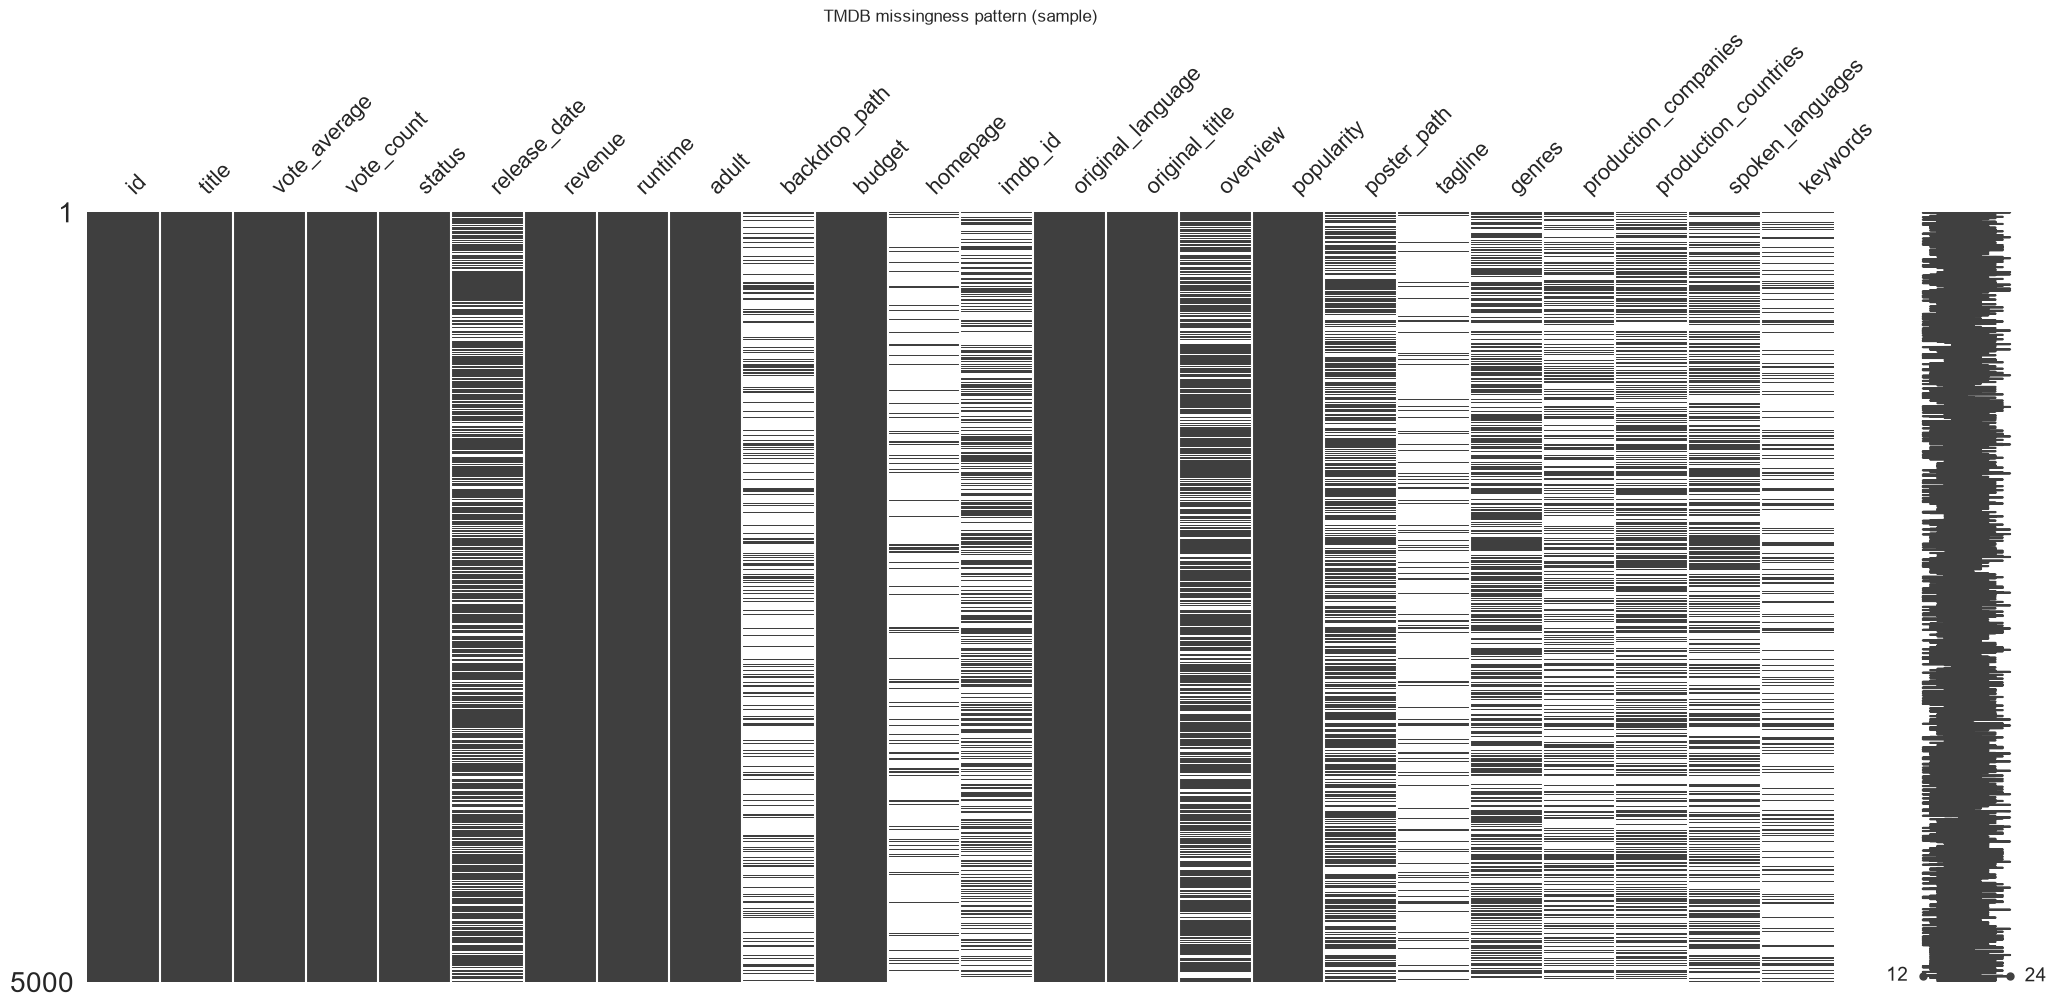

In [9]:
msno.matrix(tmdb_raw.sample(min(len(tmdb_raw), 5000), random_state=config.RANDOM_SEED))
plt.title("TMDB missingness pattern (sample)")
fig = plt.gcf()
savefig(fig, "01_tmdb_missingness_matrix_rawdata.png")
plt.show()

### Duplicate `id` check

In [10]:
tmdb_dupe_ids = int(tmdb_raw["id"].duplicated().sum())
print(f"TMDB duplicate ids: {tmdb_dupe_ids}")

TMDB duplicate ids: 1296


In [11]:
# Do duplicate-id rows actually agree on core identity fields, or do they
# genuinely conflict (which would mean the same id was reused across two
# different movies, not just re-entered with more fields filled in)?
key_cols = ["imdb_id", "title", "release_date", "vote_average"]
tmdb_dupe_id_rows = tmdb_raw[tmdb_raw["id"].duplicated(keep=False)]
n_distinct_non_null = tmdb_dupe_id_rows.groupby("id")[key_cols].agg(lambda s: s.dropna().nunique())
conflicting_ids = n_distinct_non_null[(n_distinct_non_null > 1).any(axis=1)]
n_dupe_id_groups = tmdb_dupe_id_rows["id"].nunique()
print(f"{len(conflicting_ids)} of {n_dupe_id_groups} duplicate-id groups "
      f"have conflicting (not just missing-vs-present) values in {key_cols}")

tmdb_dupe_id_rows[tmdb_dupe_id_rows["id"].isin(conflicting_ids.index)][["id"] + key_cols].sort_values("id").head()

171 of 949 duplicate-id groups have conflicting (not just missing-vs-present) values in ['imdb_id', 'title', 'release_date', 'vote_average']


,id,imdb_id,title,release_date,vote_average
591174,1192941,<NA>,एकदा येऊन तर बघा,NaT,0.0
591203,1192941,<NA>,Ekda Yeun Tar Bagha,2023-11-24,0.0
591220,1192941,<NA>,एकदा येऊन तर बघा,NaT,0.0
591228,1192941,<NA>,Ekda Yeun Tar Bagha,2023-11-24,0.0
591134,1192944,<NA>,Christmas Concert with Odd Nordstoga,2016-12-23,0.0


### Duplicate `imdb_id` check

In [12]:
tmdb_imdb_id_present = tmdb_raw["imdb_id"].dropna()
tmdb_imdb_id_present = tmdb_imdb_id_present[tmdb_imdb_id_present != "tt0000000"]
tmdb_dupe_imdb_id_mask = tmdb_imdb_id_present.duplicated(keep=False)
tmdb_dupe_imdb_ids = int(tmdb_imdb_id_present.duplicated().sum())
print(f"TMDB duplicate imdb_ids (excluding missing/placeholder values): {tmdb_dupe_imdb_ids} "
      f"out of {len(tmdb_imdb_id_present)} non-null, non-placeholder values")

tmdb_dupe_imdb_id_rows = tmdb_raw.loc[
    tmdb_imdb_id_present[tmdb_dupe_imdb_id_mask].index,
    ["id", "imdb_id", "title", "release_date"],
].sort_values("imdb_id")
tmdb_dupe_imdb_id_rows.head(20)

TMDB duplicate imdb_ids (excluding missing/placeholder values): 4518 out of 676206 non-null, non-placeholder values


,id,imdb_id,title,release_date
566921,1185484,tt0002844,Fantômas: In the Shadow of the Guillotine,1913-05-09
742879,1680343,tt0002844,Fantômas I: À l'ombre de la guillotine,1913-03-12
387557,1317649,tt0003037,Juve contre Fantômas,NaT
566923,1185482,tt0003037,Fantômas: The Man in Black,1914-09-12
751391,1628660,tt0003037,Fantômas: Juve versus Fantômas,1913-09-12
792708,1412321,tt0003037,Juve contre Fantômas,1913-09-12
343908,1663537,tt0003165,The Murderous Corpse,1913-05-09
387563,1317653,tt0003165,Fantômas - Le Mort qui tue,NaT
566949,1185457,tt0003165,Fantômas: The Dead Man Who Killed,1913-11-28
522259,1217400,tt0003930,Fantômas contre Fantômas,1914-01-05


### `vote_average` / `vote_count` zero combinations

In [13]:
vote_avg_zero = tmdb_raw["vote_average"] == 0
vote_count_zero = tmdb_raw["vote_count"] == 0

n_both_zero = int((vote_avg_zero & vote_count_zero).sum())
n_avg_nonzero_count_zero = int((~vote_avg_zero & vote_count_zero).sum())
n_avg_zero_count_nonzero = int((vote_avg_zero & ~vote_count_zero).sum())
n_both_nonzero = int((~vote_avg_zero & ~vote_count_zero).sum())

print(f"vote_average==0 and vote_count==0:    {n_both_zero}")
print(f"vote_average!=0 and vote_count==0:    {n_avg_nonzero_count_zero}")
print(f"vote_average==0 and vote_count!=0:    {n_avg_zero_count_nonzero}")
print(f"vote_average!=0 and vote_count!=0:    {n_both_nonzero}")
print(f"total:                                {len(tmdb_raw)}")

vote_average==0 and vote_count==0:    1096448
vote_average!=0 and vote_count==0:    582
vote_average==0 and vote_count!=0:    859
vote_average!=0 and vote_count!=0:    358940
total:                                1456829


DECISION: vote_count==0 means zero votes were cast, so vote_average cannot be anything but 0 in that case -- an average requires at least one value to average. The 582 rows above with vote_count==0 but vote_average!=0 are therefore logically impossible, not just noisy: corrupted/erroneous records.

Conversely, vote_count!=0 means votes were cast, so vote_average should not be zero -- vote_average==0 despite votes being cast is therefore also a corrupted/erroneous record.

### `popularity` / `vote_count` zero combinations

In [14]:
popularity_zero = tmdb_raw["popularity"] == 0
vote_count_zero = tmdb_raw["vote_count"] == 0

n_both_zero = int((popularity_zero & vote_count_zero).sum())
n_pop_nonzero_count_zero = int((~popularity_zero & vote_count_zero).sum())
n_pop_zero_count_nonzero = int((popularity_zero & ~vote_count_zero).sum())
n_both_nonzero = int((~popularity_zero & ~vote_count_zero).sum())

print(f"popularity==0 and vote_count==0:    {n_both_zero}")
print(f"popularity!=0 and vote_count==0:    {n_pop_nonzero_count_zero}")
print(f"popularity==0 and vote_count!=0:    {n_pop_zero_count_nonzero}")
print(f"popularity!=0 and vote_count!=0:    {n_both_nonzero}")
print(f"total:                              {len(tmdb_raw)}")


popularity==0 and vote_count==0:    250171
popularity!=0 and vote_count==0:    846859
popularity==0 and vote_count!=0:    5350
popularity!=0 and vote_count!=0:    354449
total:                              1456829


### Null or empty strings in `title`

In [15]:
tmdb_title_nulls, tmdb_title_empty = text_field_report(tmdb_raw, "title", "TMDB title")

TMDB title (title) — nulls: 19, empty strings: 23


### Erroneous `runtime`, `budget`, and `revenue` values

In [16]:
impossible_flags = []
if "runtime" in tmdb_raw.columns:
    impossible_flags.append(("runtime == 0", int((tmdb_raw["runtime"] == 0).sum())))
    impossible_flags.append(("runtime < 0", int((tmdb_raw["runtime"] < 0).sum())))
if "revenue" in tmdb_raw.columns:
    impossible_flags.append(("revenue < 0", int((tmdb_raw["revenue"] < 0).sum())))
if "budget" in tmdb_raw.columns:
    impossible_flags.append(("budget < 0", int((tmdb_raw["budget"] < 0).sum())))

pd.DataFrame(impossible_flags, columns=["check", "n_rows"])

,check,n_rows
0,runtime == 0,455644
1,runtime < 0,1
2,revenue < 0,1
3,budget < 0,0


## 2. Cleaning

In [17]:
tmdb_clean = tmdb_raw.copy()

### Drop URL features

In [18]:
url_features = ['homepage', 'poster_path', 'backdrop_path']
tmdb_clean = tmdb_clean.drop(columns=url_features)

URL features are not addressed in this dissertation.

### Filter to `status == 'Released'`

This filter is necessary because `vote_average` is only meaningful once a movie's status is `'Released'` -- if `vote_average > 0` while `status` is not `'Released'`, those records are erroneous. Some features, like `imdb_id`, are also only assigned after a movie is released.

In [19]:
status_counts = tmdb_clean["status"].value_counts(dropna=False)
status_pct = (status_counts / len(tmdb_clean) * 100).round(2)
pd.DataFrame({"count": status_counts, "pct": status_pct})

,count,pct
status,,
Released,1402648,96.28
In Production,24534,1.68
Post Production,16237,1.11
Planned,12179,0.84
Rumored,855,0.06
Canceled,376,0.03


In [20]:
# Verify the claim behind the filter across every column, not just the
# handful expected to be post-release-only.
released_mask = tmdb_clean["status"] == "Released"
missingness_by_status = pd.DataFrame({
    "% missing (Released)": tmdb_clean.loc[released_mask].isnull().mean() * 100,
    "% missing (non-Released)": tmdb_clean.loc[~released_mask].isnull().mean() * 100,
})
missingness_by_status["gap"] = missingness_by_status["% missing (non-Released)"] - missingness_by_status["% missing (Released)"]
missingness_by_status.round(2).sort_values("gap", ascending=False)

,% missing (Released),% missing (non-Released),gap
release_date,21.58,57.09,35.51
imdb_id,52.87,72.17,19.31
overview,23.09,23.86,0.77
original_title,0.00,0.01,0.01
title,0.00,0.01,0.01
status,0.00,0.00,0.00
vote_count,0.00,0.00,0.00
vote_average,0.00,0.00,0.00
id,0.00,0.00,0.00
adult,0.00,0.00,0.00


In [21]:
tmdb_clean = tmdb_clean.copy()
shape_before_status_filter = tmdb_clean.shape
tmdb_clean = tmdb_clean[tmdb_clean["status"] == "Released"].copy()
tmdb_shape_after_status_filter = tmdb_clean.shape
print(f"TMDB shape before status filter: {shape_before_status_filter}")
print(f"TMDB shape after status filter: {tmdb_shape_after_status_filter}")

TMDB shape before status filter: (1456829, 21)
TMDB shape after status filter: (1402648, 21)


### Filter to `adult == False`

Personal choice of not dealing with adult-themed movies.
Also, this filter is not 100% correct, as the values of this will persist

In [22]:
tmdb_shape_before_adult_filter = tmdb_clean.shape
tmdb_clean = tmdb_clean[tmdb_clean["adult"] == False]
print(f"Shape: {tmdb_shape_before_adult_filter} -> {tmdb_clean.shape}")

Shape: (1402648, 21) -> (1259173, 21)


### Drop the filter features

After filtering, each of these features has only one remaining value: `status` is always `'Released'` and `adult` is always `False`. Keeping them would just be extra features with no information to learn from.

In [23]:
filtered_features = ["status", "adult"]
tmdb_clean = tmdb_clean.drop(columns=filtered_features)

### Recode `budget`/`revenue` zeros as NaN

Realistically, `budget > 0` and `revenue > 0`.

In [24]:
zero_recode_report = {}
for col in ["budget", "revenue"]:
    pct_zero = float((tmdb_clean[col] == 0).mean() * 100)
    zero_recode_report[col] = pct_zero
    tmdb_clean[col] = tmdb_clean[col].replace(0, np.nan)
    print(f"{col}: {pct_zero:.1f}% of rows were 0 -> recoded as NaN")

budget: 93.8% of rows were 0 -> recoded as NaN
revenue: 98.1% of rows were 0 -> recoded as NaN


### Recode `runtime` zeros as NaN

The runtime of a movie cannot be zero.

In [25]:
pct_zero_runtime = float((tmdb_clean["runtime"] == 0).mean() * 100)
tmdb_clean["runtime"] = tmdb_clean["runtime"].replace(0, np.nan)
print(f"runtime: {pct_zero_runtime:.1f}% of rows were 0 -> recoded as NaN")

runtime: 30.5% of rows were 0 -> recoded as NaN


### Recode negative `runtime`/`revenue` values as NaN

In [26]:
tmdb_neg_recode_report = {}
for col in ["runtime", "revenue"]:
    pct_negative = float((tmdb_clean[col] < 0).mean() * 100)
    tmdb_neg_recode_report[col] = pct_negative
    tmdb_clean[col] = tmdb_clean[col].where(tmdb_clean[col] >= 0, np.nan)
    print(f"{col}: {pct_negative:.4f}% of rows were negative -> recoded as NaN")

runtime: 0.0001% of rows were negative -> recoded as NaN
revenue: 0.0001% of rows were negative -> recoded as NaN


### Drop `runtime` > 200

The 99th-percentile check above confirms `runtime`'s extreme skew is a thin tail: drops rows with `runtime > 200`.

In [27]:
print(f"99th percentile of runtime: {tmdb_clean['runtime'].quantile(0.99):.1f} minutes")

99th percentile of runtime: 189.0 minutes


In [28]:
shape_before_runtime_cap = tmdb_clean.shape
tmdb_clean = tmdb_clean[tmdb_clean["runtime"] <= 200]
pct_dropped_runtime = (
    (shape_before_runtime_cap[0] - tmdb_clean.shape[0])
    / shape_before_runtime_cap[0] * 100
)
print(
    f"tmdb_clean: {shape_before_runtime_cap} -> {tmdb_clean.shape} "
    f"({pct_dropped_runtime:.2f}% dropped)"
)

tmdb_clean: (1259173, 19) -> (867453, 19) (31.11% dropped)


### Drop missing `runtime` rows

In [29]:
tmdb_shape_before_runtime_drop = tmdb_clean.shape
tmdb_clean = tmdb_clean[tmdb_clean["runtime"].notna()]
print(f"Dropped {tmdb_shape_before_runtime_drop[0] - tmdb_clean.shape[0]} rows with runtime == NaN")
print(f"Shape: {tmdb_shape_before_runtime_drop} -> {tmdb_clean.shape}")

Dropped 0 rows with runtime == NaN
Shape: (867453, 19) -> (867453, 19)


### Drop duplicate `id` rows

In [30]:
tmdb_shape_before_dedup = tmdb_clean.shape
tmdb_clean = (
    tmdb_clean.assign(_null_count=tmdb_clean.isnull().sum(axis=1))
    .sort_values("_null_count")
    .drop_duplicates(subset="id", keep="first")
    .drop(columns="_null_count")
    .sort_index()
)
tmdb_shape_after_dedup = tmdb_clean.shape
tmdb_n_dupe_ids_dropped = tmdb_shape_before_dedup[0] - tmdb_shape_after_dedup[0]
print(f"TMDB: dropped {tmdb_n_dupe_ids_dropped} duplicate-id rows (kept the most complete row per id)")
print(f"Shape before dedup: {tmdb_shape_before_dedup}, after: {tmdb_shape_after_dedup}")

TMDB: dropped 414 duplicate-id rows (kept the most complete row per id)
Shape before dedup: (867453, 19), after: (867039, 19)


### Validate `imdb_id` duplicates before dropping them

Duplicate `imdb_id` rows in this dataset are largely localized/dubbed re-entries of the same movie (see the raw duplicate-`imdb_id` sample in Section 1), so `title`/`original_title`/`overview`/`tagline` are expected to differ and are excluded here. `vote_average`/`vote_count` are also excluded -- they are per-TMDB-entry counters, not movie-level facts, so they're expected to differ across separate listings of the same film. This checks whether the facts that should NOT depend on either of those -- `budget`, `revenue`, `runtime`, `release_date` -- have a genuine conflict (two non-null, disagreeing values) within each duplicate-`imdb_id` group, to confirm the "keep the most complete row" dedup below is safe rather than merging genuinely different records.

In [31]:
CORE_FACT_COLS = ["budget", "revenue", "runtime", "release_date"]

dupe_imdb_mask = tmdb_clean["imdb_id"].duplicated(keep=False) & tmdb_clean["imdb_id"].notna()
tmdb_dupe_imdb_groups = tmdb_clean[dupe_imdb_mask]

def has_conflict(group):
    # A real conflict: two non-null values disagree on some column.
    # A row with a missing value doesn't count -- that's incompleteness, not conflict.
    return any(group[col].dropna().nunique() > 1 for col in CORE_FACT_COLS)

conflicting_imdb_groups = tmdb_dupe_imdb_groups.groupby("imdb_id").filter(has_conflict)
n_conflicting_groups = conflicting_imdb_groups["imdb_id"].nunique()
n_total_dupe_groups = tmdb_dupe_imdb_groups["imdb_id"].nunique()
print(f"{n_conflicting_groups} of {n_total_dupe_groups} duplicate-imdb_id groups have a genuine "
      f"conflict (two non-null, disagreeing values) in {CORE_FACT_COLS}")

598 of 1176 duplicate-imdb_id groups have a genuine conflict (two non-null, disagreeing values) in ['budget', 'revenue', 'runtime', 'release_date']


### Drop duplicate `imdb_id` rows

In [32]:
tmdb_shape_before_imdb_dedup = tmdb_clean.shape

imdb_id_present = tmdb_clean["imdb_id"].notna()
tmdb_imdb_dupes = tmdb_clean[imdb_id_present]
tmdb_no_imdb_id = tmdb_clean[~imdb_id_present]

tmdb_imdb_dupes = (
    tmdb_imdb_dupes.assign(_null_count=tmdb_imdb_dupes.isnull().sum(axis=1))
    .sort_values(["_null_count", "id"])
    .drop_duplicates(subset="imdb_id", keep="first")
    .drop(columns="_null_count")
)

tmdb_clean = pd.concat([tmdb_imdb_dupes, tmdb_no_imdb_id]).sort_index()

tmdb_shape_after_imdb_dedup = tmdb_clean.shape
tmdb_n_dupe_imdb_ids_dropped = tmdb_shape_before_imdb_dedup[0] - tmdb_shape_after_imdb_dedup[0]
print(f"TMDB: dropped {tmdb_n_dupe_imdb_ids_dropped} duplicate-imdb_id rows (kept the most complete row per imdb_id, tie-broken by lowest id)")
print(f"Shape before imdb_id dedup: {tmdb_shape_before_imdb_dedup}, after: {tmdb_shape_after_imdb_dedup}")

TMDB: dropped 2158 duplicate-imdb_id rows (kept the most complete row per imdb_id, tie-broken by lowest id)
Shape before imdb_id dedup: (867039, 19), after: (864881, 19)


### Drop rows with missing `title`

In [33]:
tmdb_shape_before_title_drop = tmdb_clean.shape
tmdb_clean = tmdb_clean[tmdb_clean["title"].notna()]
print(f"Dropped {tmdb_shape_before_title_drop[0] - tmdb_clean.shape[0]} rows with title == NaN")
print(f"Shape: {tmdb_shape_before_title_drop} -> {tmdb_clean.shape}")

Dropped 6 rows with title == NaN
Shape: (864881, 19) -> (864875, 19)


### Remove inconsistent `vote_average`/`vote_count` rows

In [34]:
tmdb_shape_before_vote_fix = tmdb_clean.shape
bad_vote_mask = (
    ((tmdb_clean["vote_average"] != 0) & (tmdb_clean["vote_count"] == 0))
    | ((tmdb_clean["vote_average"] == 0) & (tmdb_clean["vote_count"] != 0))
)
tmdb_clean = tmdb_clean[~bad_vote_mask]
print(f"Dropped {int(bad_vote_mask.sum())} rows with inconsistent vote_average/vote_count")
print(f"Shape: {tmdb_shape_before_vote_fix} -> {tmdb_clean.shape}")

Dropped 1017 rows with inconsistent vote_average/vote_count
Shape: (864875, 19) -> (863858, 19)


### Convert list-valued string features to list type

Covers TMDB `genres`, `keywords`, `production_companies`,
`production_countries`, and `spoken_languages`. TMDB stores these as
comma-separated plain strings rather than JSON, so `parse_list_field()`
(defined in Setup) tries `json.loads` / `ast.literal_eval` first and
falls back to a comma split otherwise.

In [35]:
list_features = ["genres", "keywords", "production_companies", "production_countries", "spoken_languages"]

#### Parsing verification

In [36]:
for col, df_ in [
    ("genres", tmdb_clean),
    ("keywords", tmdb_clean),
    ("production_companies", tmdb_clean),
    ("production_countries", tmdb_clean),
    ("spoken_languages", tmdb_clean),
]:
    sample_val = df_[col].dropna().iloc[0]
    print(f"--- {col} ---")
    print("raw:", sample_val)
    print("parsed:", parse_list_field(sample_val))
    print()

--- genres ---
raw: Action, Science Fiction, Adventure
parsed: ['Action', 'Science Fiction', 'Adventure']

--- keywords ---
raw: rescue, mission, dream, airplane, paris, france, virtual reality, kidnapping, philosophy, spy, allegory, manipulation, car crash, heist, memory, architecture, los angeles, california, dream world, subconscious
parsed: ['rescue', 'mission', 'dream', 'airplane', 'paris', 'france', 'virtual reality', 'kidnapping', 'philosophy', 'spy', 'allegory', 'manipulation', 'car crash', 'heist', 'memory', 'architecture', 'los angeles', 'california', 'dream world', 'subconscious']

--- production_companies ---
raw: Legendary Pictures, Syncopy, Warner Bros. Pictures
parsed: ['Legendary Pictures', 'Syncopy', 'Warner Bros. Pictures']

--- production_countries ---
raw: United Kingdom, United States of America
parsed: ['United Kingdom', 'United States of America']

--- spoken_languages ---
raw: English, French, Japanese, Swahili
parsed: ['English', 'French', 'Japanese', 'Swahili'

#### Apply parsing

In [37]:
for col in list_features:
    tmdb_clean[col] = tmdb_clean[col].apply(parse_list_field)


# Replace empty lists with NaN
for col in list_features:
    tmdb_clean[col] = tmdb_clean[col].apply(lambda lst: lst if lst else np.nan)

### Missingness after cleaning

In [38]:
tmdb_missing = pd.DataFrame(
    {
        "n_missing": tmdb_clean.isnull().sum(),
        "pct_missing": tmdb_clean.isnull().mean() * 100,
    }
).sort_values("pct_missing", ascending=False)
tmdb_missing

,n_missing,pct_missing
revenue,843246,97.613960
budget,802535,92.901264
tagline,699093,80.926842
keywords,623351,72.158966
production_companies,481778,55.770509
imdb_id,365952,42.362518
production_countries,361781,41.879684
spoken_languages,331674,38.394505
genres,275269,31.865075
release_date,122363,14.164712


Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\01\01_tmdb_missingness_matrix_cleandata.png


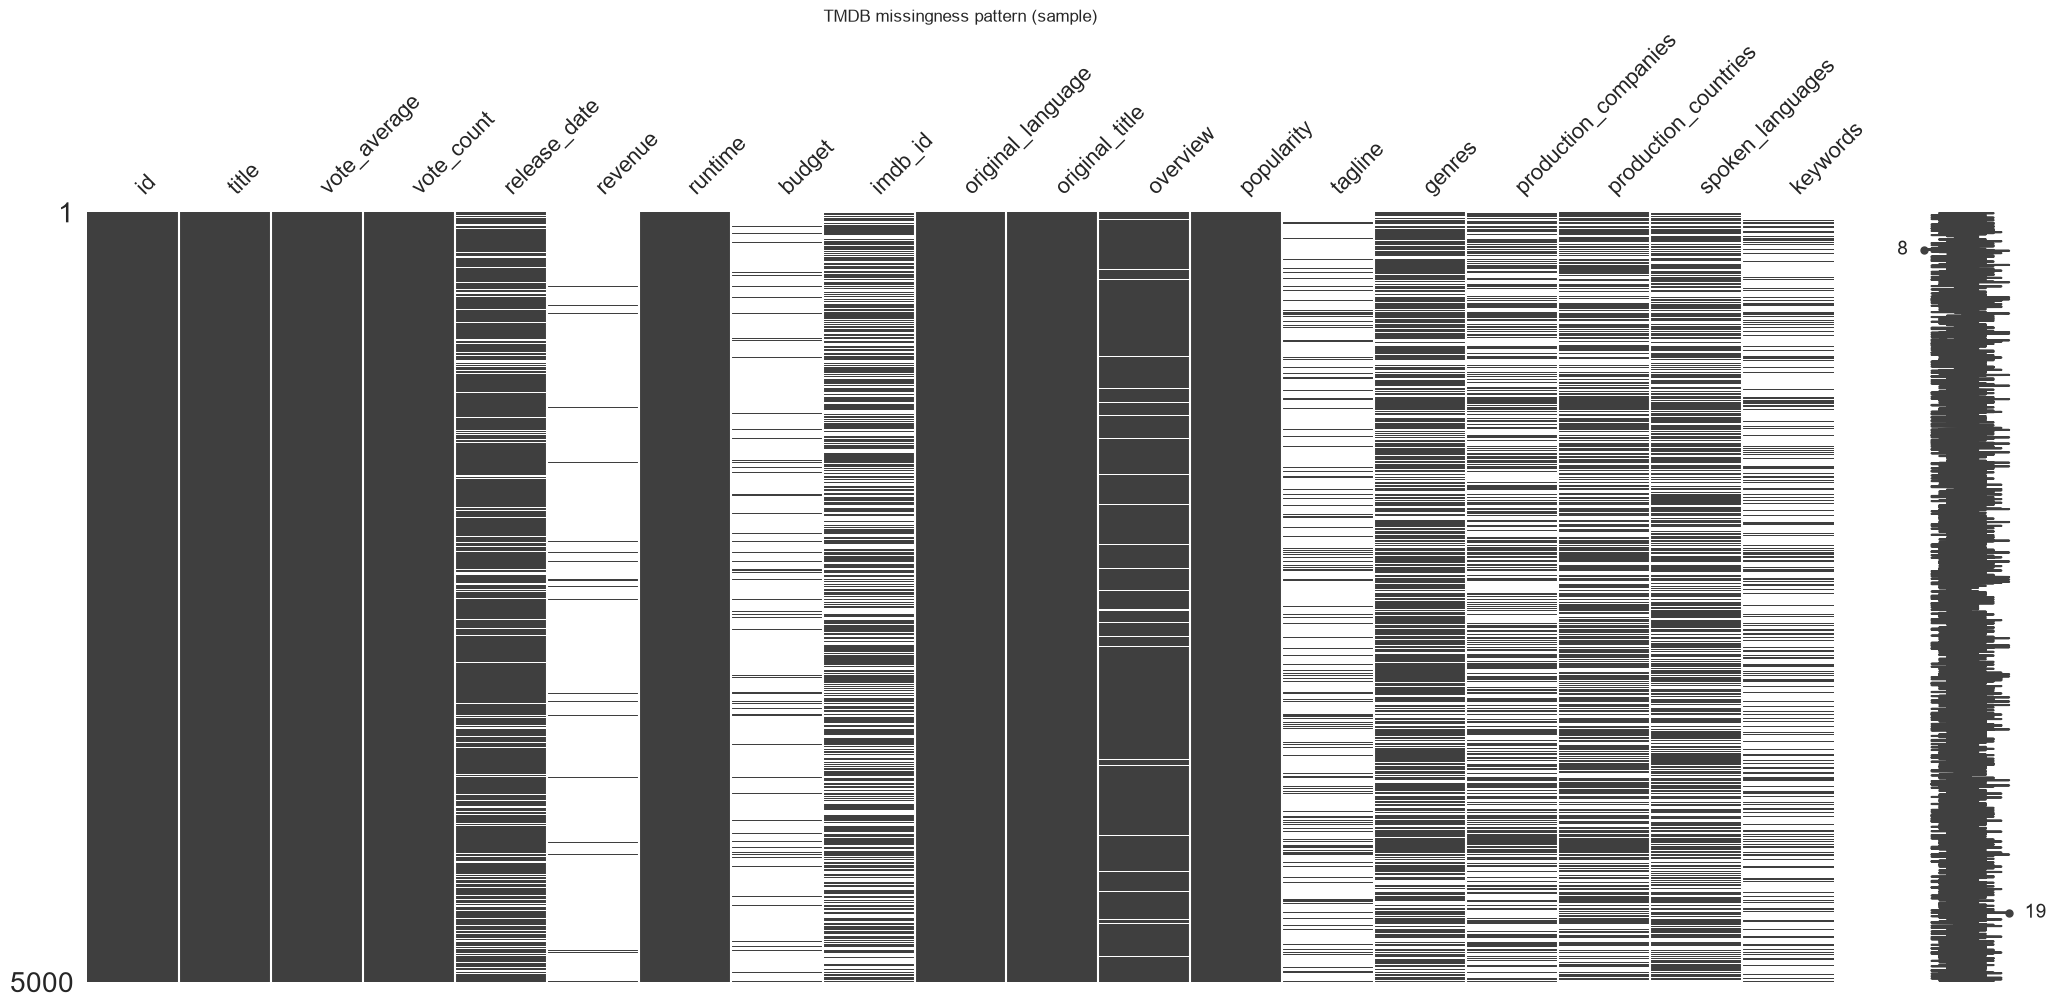

In [39]:
msno.matrix(tmdb_clean.sample(min(len(tmdb_clean), 5000), random_state=config.RANDOM_SEED))
plt.title("TMDB missingness pattern (sample)")
fig = plt.gcf()
savefig(fig, "01_tmdb_missingness_matrix_cleandata.png")
plt.show()

### View dataset after cleaning

In [40]:
tmdb_clean.sample(10, random_state=config.RANDOM_SEED)

,id,title,vote_average,vote_count,release_date,revenue,runtime,budget,imdb_id,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
630397,1606451,Atopia,0.000,0,NaT,NaN,86.0,5000.0,tt5969686,en,Atopia,Carl is the unwitting subject of simulations b...,0.0000,<NA>,NaN,NaN,NaN,NaN,NaN
1100498,211698,The North Pole Conspiracy,0.000,0,2010-12-20,NaN,46.0,NaN,<NA>,en,The North Pole Conspiracy,"Two Arctic explorers fought harsh, bitter elem...",0.6000,<NA>,NaN,[Storyhouse Productions],[Germany],NaN,NaN
1442359,892246,Versus,0.000,0,2020-11-12,NaN,31.0,NaN,<NA>,zh,對摔,"On the Matsu Islands, young wrestlers enjoy th...",0.6000,<NA>,[Documentary],NaN,[Taiwan],NaN,NaN
103785,444343,Cold Tango,6.200,6,2017-06-22,NaN,98.0,NaN,tt7081574,ru,Холодное танго,By miracle he avoided death and returns to the...,2.9390,<NA>,"[Romance, Drama, War]",[Studio SLON],[Russia],[Russian],NaN
384351,1719953,Grandma's House,0.000,0,NaT,NaN,4.0,NaN,<NA>,en,Grandma's House,A short interview with my grandmother and her ...,0.0071,<NA>,[Documentary],NaN,NaN,NaN,NaN
1193873,1013763,It’s 50 euros,0.000,0,2021-12-24,NaN,12.0,NaN,<NA>,ca,Son 50 euros,Two men meet for a coffee in a bar. As they ta...,0.6000,SOMETIMES IT GETS TO THE POINT WHERE MONEY TAL...,"[Comedy, Action]",NaN,NaN,[Catalan],"[one location, short film, student film]"
56442,565326,Before You Know It,5.125,16,2019-08-30,NaN,98.0,NaN,tt8856090,en,Before You Know It,A pair of sisters find out that the mother the...,2.1220,Family and other embarrassments.,[Comedy],NaN,NaN,[English],NaN
1071344,332395,Shep Comes Home,0.000,0,1948-12-03,NaN,60.0,NaN,tt0038935,en,Shep Comes Home,"Little Larry Havens, whose father died in WWII...",0.9500,THRILLING ADVENTURE OF A BOY AND HIS DOG...in ...,"[Action, Adventure, Crime]",[Robert L. Lippert Productions],[United States of America],[English],"[dog, post world war ii, modern west]"
157999,66310,Dharma Yuddam,6.000,3,1979-06-29,NaN,136.0,NaN,tt0186963,ta,தர்மயுத்தம்,Rajini's parents are killed by Thengai Sriniva...,1.6430,<NA>,"[Action, Drama]",[Charusuchitra Films],[India],[Tamil],NaN
77946,592875,Uriyadi 2,7.000,10,2019-04-05,NaN,119.0,NaN,tt10121762,ta,உறியடி II,A young man struggles for justice for the vict...,2.5920,<NA>,"[Action, Thriller]","[2D Entertainment, Souvenir Productions]",[India],[Tamil],"[fight for justice, chemical leak, chemical pl..."


## 3. Candidate outcome variable distribution

`vote_average` is chosen as the target label. This is needed for the supervised learning paradigm.

### `vote_average` distribution

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\01\01_tmdb_vote_average_hist.png


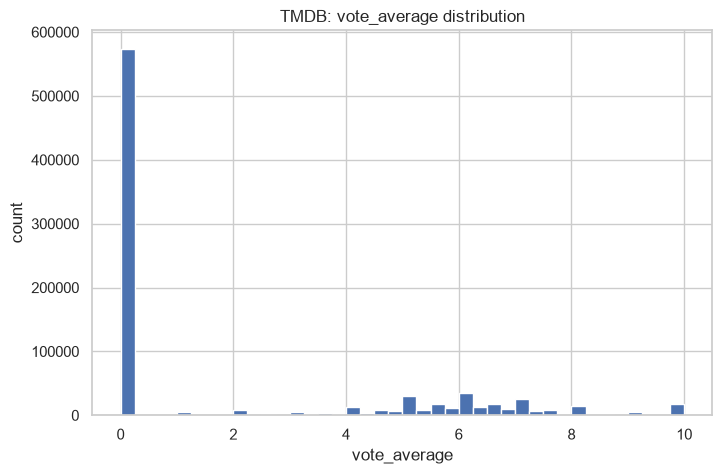

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
tmdb_clean["vote_average"].dropna().hist(bins=40, ax=ax)
ax.set_title("TMDB: vote_average distribution")
ax.set_xlabel("vote_average")
ax.set_ylabel("count")
savefig(fig, "01_tmdb_vote_average_hist.png")
plt.show()

### `vote_count` threshold counts

In [42]:
for threshold in [1, 5, 10, 20, 50]:
    print(f"vote_count >= {threshold}: {(tmdb_clean['vote_count'] >= threshold).sum():,} rows")

vote_count >= 1: 289,808 rows
vote_count >= 5: 120,883 rows
vote_count >= 10: 77,101 rows
vote_count >= 20: 49,698 rows
vote_count >= 50: 27,746 rows


## 4. Save the cleaned file

In [43]:
tmdb_clean_path = PROCESSED_DIR / "tmdb_clean.parquet"

tmdb_clean.to_parquet(tmdb_clean_path, index=False)

print(f"Saved: {tmdb_clean_path} ({tmdb_clean.shape})")

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\data\processed\tmdb_clean.parquet ((863858, 19))


## 5. Log summary

In [44]:
findings = {
    "TMDB rows (raw -> cleaned)": f"{tmdb_shape_raw[0]:,} -> {tmdb_clean.shape[0]:,}",
    "TMDB columns (raw -> cleaned)": f"{tmdb_shape_raw[1]} -> {tmdb_clean.shape[1]}",
    "Raw memory footprint (deep)": f"{tmdb_mem_mb:,.1f} MB",
    "Dropped: status != 'Released'": f"{shape_before_status_filter[0] - tmdb_shape_after_status_filter[0]:,} rows",
    "Dropped: adult == True": f"{tmdb_shape_before_adult_filter[0] - tmdb_shape_before_dedup[0]:,} rows",
    "Recoded budget/revenue zeros as NaN": f"{zero_recode_report['budget']:.1f}% / {zero_recode_report['revenue']:.1f}% of rows",
    "Recoded runtime zeros as NaN": f"{pct_zero_runtime:.1f}% of rows",
    "Recoded negative runtime/revenue as NaN": f"{tmdb_neg_recode_report['runtime']:.4f}% / {tmdb_neg_recode_report['revenue']:.4f}% of rows",
    "Dropped: runtime > 200 minutes rows": f"{pct_dropped_runtime:.2f}% of rows dropped (runtime > 200)",
    "Dropped: missing runtime rows": f"{tmdb_shape_before_runtime_drop[0] - tmdb_shape_before_dedup[0]:,}",
    "Dropped: duplicate id rows": f"{tmdb_n_dupe_ids_dropped:,} (kept most complete row per id)",
    "Dropped: duplicate imdb_id rows": f"{tmdb_n_dupe_imdb_ids_dropped:,} (kept most complete row per imdb_id, tie-broken by lowest id)",
    "Dropped: missing title rows": f"{tmdb_shape_before_title_drop[0] - tmdb_shape_before_vote_fix[0]:,}",
    "Dropped: inconsistent vote_average/vote_count rows": f"{int(bad_vote_mask.sum()):,}",
    "Final missingness (top 3 by %)": tmdb_missing.head(3)["pct_missing"].round(2).to_dict(),
    "vote_count >= 1 / >= 5 / >= 10": (
        f"{(tmdb_clean['vote_count'] >= 1).sum():,} / "
        f"{(tmdb_clean['vote_count'] >= 5).sum():,} / "
        f"{(tmdb_clean['vote_count'] >= 10).sum():,} rows "
        "(vote_count filter deferred to modeling stage, not yet applied)"
    ),
    "Saved to": str(tmdb_clean_path),
}

log_findings(
    title="01 Overview & Cleaning: TMDB -- summary",
    findings=findings,
    figures=[
        "reports/figures/01/01_tmdb_missingness_matrix_cleandata.png",
        "reports/figures/01/01_tmdb_vote_average_hist.png",
    ],
)
print("Logged summary to reports/eda_log.md")

Logged summary to reports/eda_log.md
